In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_parquet(
    "data/artifacts/03_train.parquet"
)

print("Shape:", train.shape)
display(train.head())

Shape: (67533, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_lat,customer_lng,...,total_product_volume_cm3,avg_product_photos_qty,avg_product_name_length,avg_product_description_length,seller_customer_distance_km,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_delayed
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,-20.585396,-47.863156,...,12288.0,1.0,34.0,1036.0,566.040211,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,-23.581321,-46.635726,...,4096.0,3.0,63.0,1642.0,708.535291,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,-28.291275,-53.501401,...,4096.0,1.0,39.0,518.0,915.734331,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,-22.936855,-43.359961,...,3332.0,1.0,25.0,823.0,358.782919,b8b8726af116a5cfb35b0315ecef9172,22770,rio de janeiro,RJ,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,-30.040958,-51.212970,...,4160.0,1.0,39.0,141.0,818.048765,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,0


In [2]:
print(train.dtypes)

order_id                                  object
customer_id                               object
order_status                              object
order_purchase_timestamp          datetime64[ns]
order_approved_at                         object
order_delivered_carrier_date              object
order_delivered_customer_date     datetime64[ns]
order_estimated_delivery_date     datetime64[ns]
customer_lat                             float64
customer_lng                             float64
customer_geo_points                      float64
seller_lat                               float64
seller_lng                               float64
seller_geo_points                        float64
num_sellers                              float64
num_seller_states                        float64
num_seller_cities                        float64
total_price                              float64
total_freight                            float64
num_items                                float64
num_unique_products 

In [3]:
print("\nعدد الصفوف:", train.shape[0])
print("عدد الأعمدة:", train.shape[1])


عدد الصفوف: 67533
عدد الأعمدة: 42


In [4]:
missing = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing[missing > 0]
)

avg_product_description_length    1197
avg_product_photos_qty            1197
avg_product_name_length           1197
num_reviews                        515
avg_review_score                   515
seller_customer_distance_km        344
customer_lat                       181
customer_lng                       181
customer_geo_points                181
seller_lat                         164
seller_lng                         164
avg_product_weight_g                16
avg_product_width_cm                16
avg_product_height_cm               16
avg_product_length_cm               16
order_approved_at                   14
total_payment                        1
order_delivered_carrier_date         1
num_payment_types                    1
num_payment_records                  1
dtype: int64

In [5]:
categorical_cols = [
    "order_status",
    "customer_city",
    "customer_state"
]

for col in categorical_cols:

    print("\n" + "=" * 60)
    print("العمود:", col)
    print("عدد القيم المختلفة:", train[col].nunique())

    display(
        train[col]
        .value_counts(dropna=False)
        .head(15)
    )


العمود: order_status
عدد القيم المختلفة: 2


order_status
delivered    67527
canceled         6
Name: count, dtype: int64


العمود: customer_city
عدد القيم المختلفة: 3747


customer_city
sao paulo                9921
rio de janeiro           4780
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
niteroi                   559
santo andre               518
osasco                    485
santos                    456
fortaleza                 454
Name: count, dtype: int64


العمود: customer_state
عدد القيم المختلفة: 27


customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
Name: count, dtype: int64

In [6]:
status_delay = pd.crosstab(
    train["order_status"],
    train["is_delayed"],
    normalize="index"
).mul(100).round(2)

display(status_delay)

is_delayed,0,1
order_status,,
canceled,83.33,16.67
delivered,90.97,9.03


In [7]:
numeric_features = [
    "total_price",
    "total_freight",
    "num_items",
    "seller_customer_distance_km"
]

for col in numeric_features:

    print("\n" + "=" * 60)
    print(col)

    display(
        train.groupby("is_delayed")[col]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std"
        )
    )


total_price


,count,mean,median,std
is_delayed,,,,
0,61436,134.506741,84.99,203.737309
1,6097,149.767376,89.99,218.801051



total_freight


,count,mean,median,std
is_delayed,,,,
0,61436,21.950632,16.60,19.604236
1,6097,25.202941,18.12,23.414034



num_items


,count,mean,median,std
is_delayed,,,,
0,61436,1.144834,1.0,0.544545
1,6097,1.114319,1.0,0.510603



seller_customer_distance_km


,count,mean,median,std
is_delayed,,,,
0,61130,598.208414,437.063057,585.272072
1,6059,778.000656,550.654342,670.666585


In [8]:
train["purchase_year"] = (
    train["order_purchase_timestamp"].dt.year
)

train["purchase_month"] = (
    train["order_purchase_timestamp"].dt.month
)

train["purchase_weekday"] = (
    train["order_purchase_timestamp"].dt.dayofweek
)

In [9]:
monthly_delay = (
    train.groupby("purchase_month")["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(monthly_delay)

purchase_month
1      6.23
2     13.42
3     17.15
4      7.02
5      3.61
6      3.86
7      3.43
8      3.32
9      5.23
10     5.05
11    14.31
12     8.38
Name: is_delayed, dtype: float64

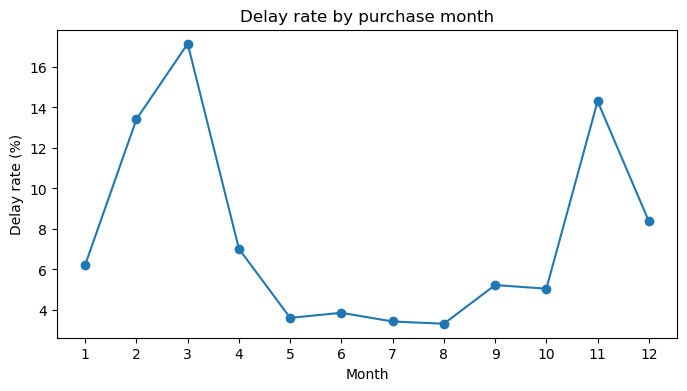

In [10]:
plt.figure(figsize=(8, 4))

monthly_delay.plot(
    kind="line",
    marker="o"
)

plt.title("Delay rate by purchase month")
plt.xlabel("Month")
plt.ylabel("Delay rate (%)")
plt.xticks(range(1, 13))

plt.show()

In [11]:
weekday_delay = (
    train.groupby("purchase_weekday")["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(weekday_delay)

purchase_weekday
0    10.02
1     9.26
2     8.61
3     8.29
4     9.47
5     8.97
6     8.38
Name: is_delayed, dtype: float64

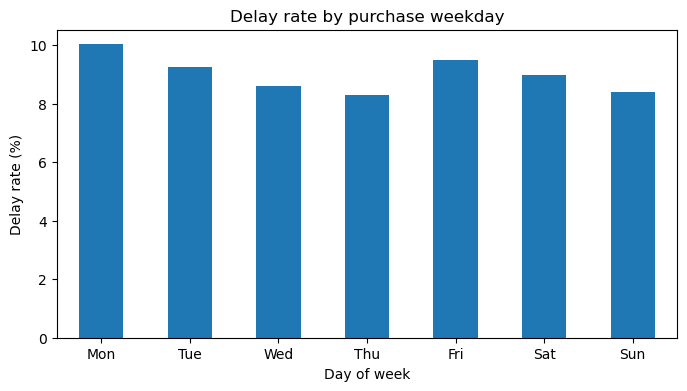

In [12]:
plt.figure(figsize=(8, 4))

weekday_delay.plot(
    kind="bar"
)

plt.title("Delay rate by purchase weekday")
plt.xlabel("Day of week")
plt.ylabel("Delay rate (%)")
plt.xticks(range(7), [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
], rotation=0)

plt.show()

In [13]:
state_delay = (
    train.groupby("customer_state")["is_delayed"]
    .agg(
        delay_rate="mean",
        orders="count"
    )
)

state_delay["delay_rate"] = (
    state_delay["delay_rate"] * 100
).round(2)

display(
    state_delay.sort_values(
        "delay_rate",
        ascending=False
    ).head(15)
)

,delay_rate,orders
customer_state,,
AL,27.85,298
MA,21.53,548
CE,18.25,948
RR,17.24,29
SE,17.07,246
PI,16.67,348
RJ,16.58,8967
BA,15.00,2307
PA,13.37,718


In [14]:
train["distance_band"] = pd.cut(
    train["seller_customer_distance_km"],
    bins=[0, 100, 300, 500, 1000, 2000, np.inf],
    labels=[
        "0-100",
        "100-300",
        "300-500",
        "500-1000",
        "1000-2000",
        "2000+"
    ]
)
distance_delay = (
    train.groupby("distance_band", observed=False)["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
)

display(distance_delay)

distance_band
0-100         4.85
100-300       6.90
300-500       9.23
500-1000      9.98
1000-2000    12.09
2000+        15.24
Name: is_delayed, dtype: float64

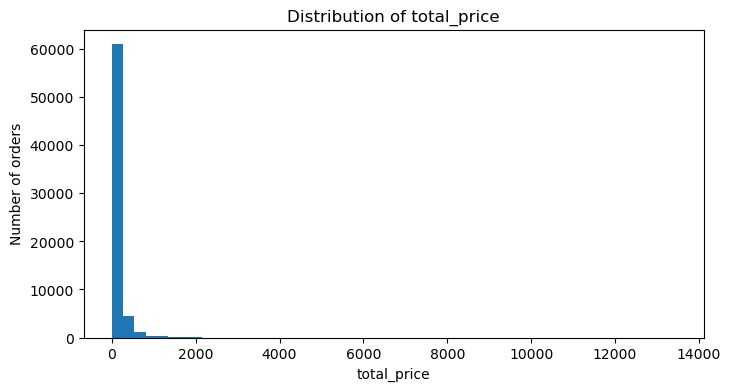

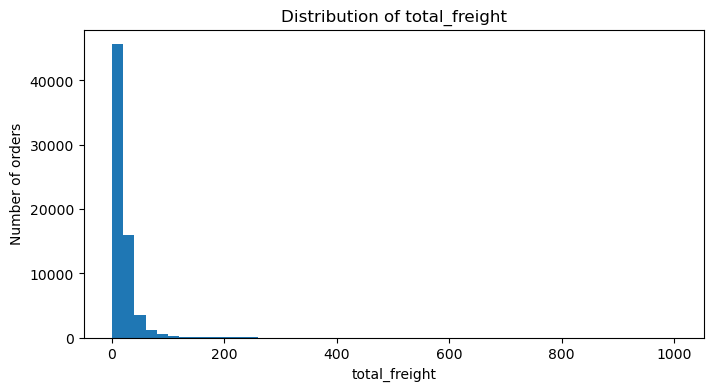

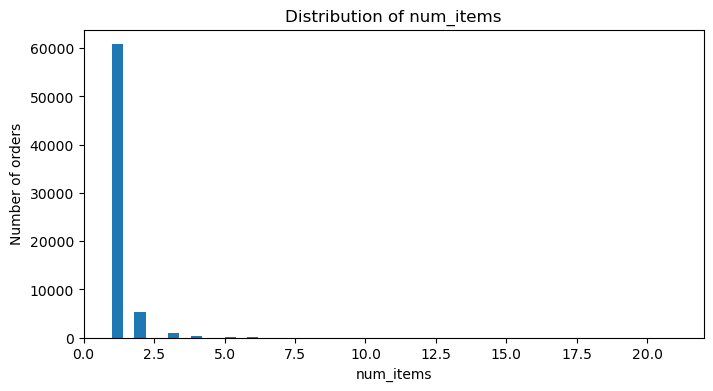

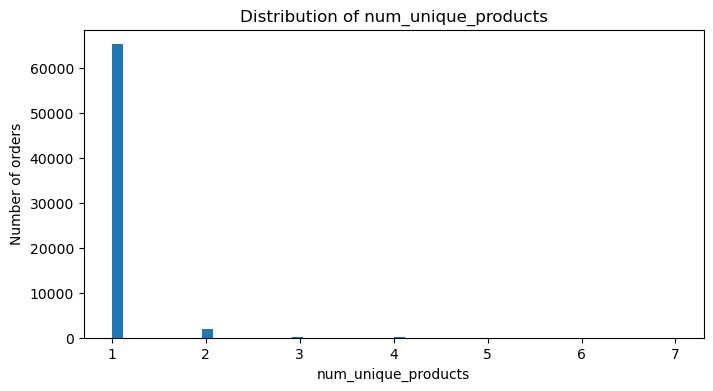

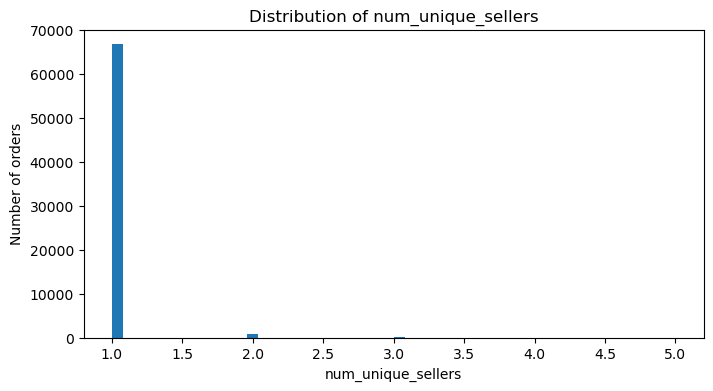

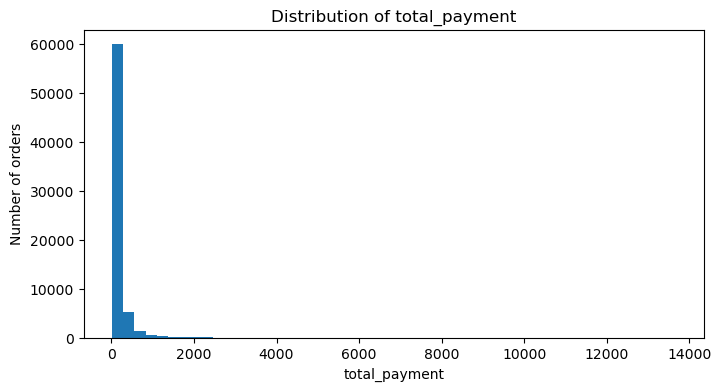

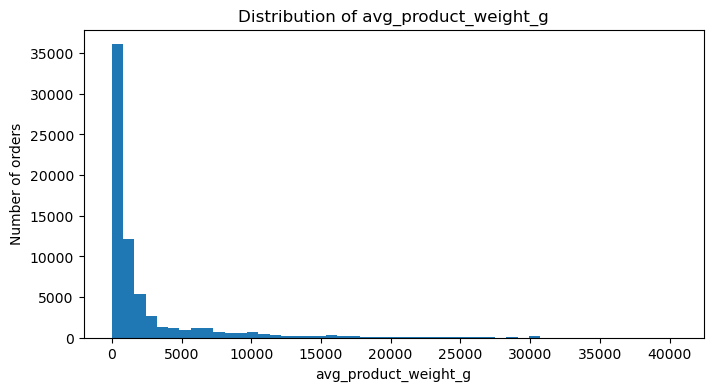

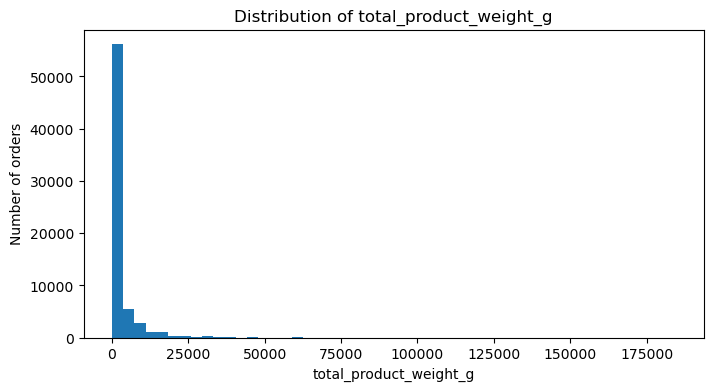

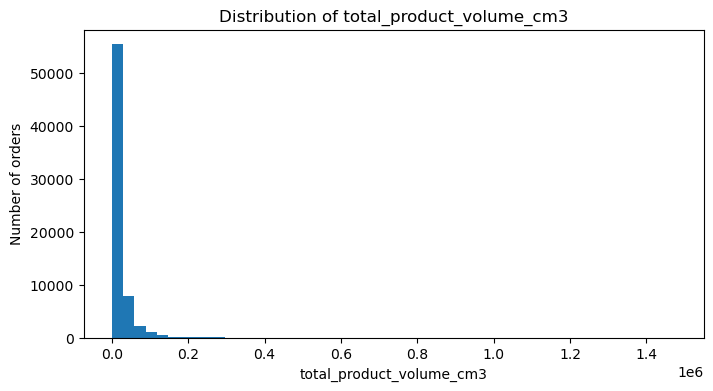

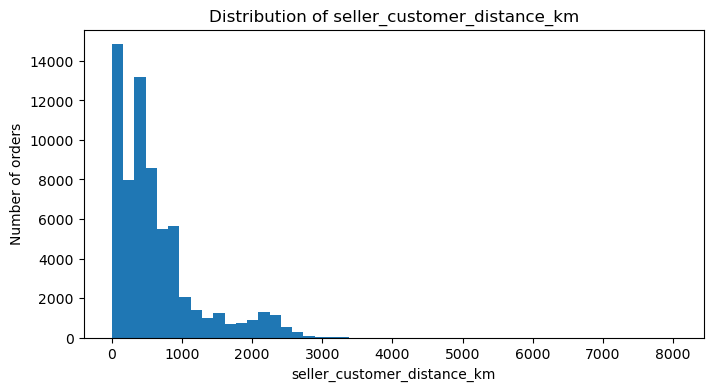

In [15]:
numeric_features = [
    "total_price",
    "total_freight",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "total_payment",
    "avg_product_weight_g",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "seller_customer_distance_km"
]

for col in numeric_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        train[col].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of orders")

    plt.show()

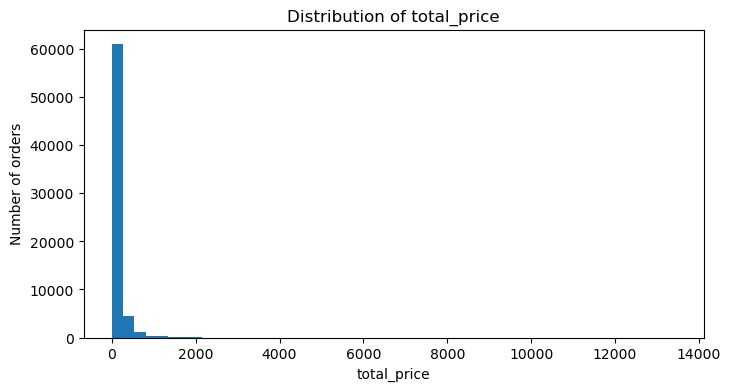

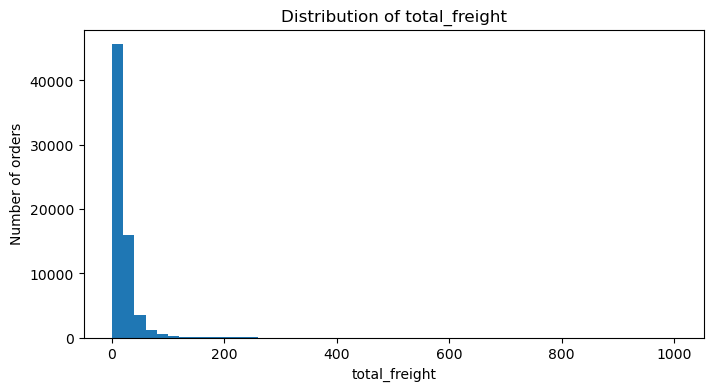

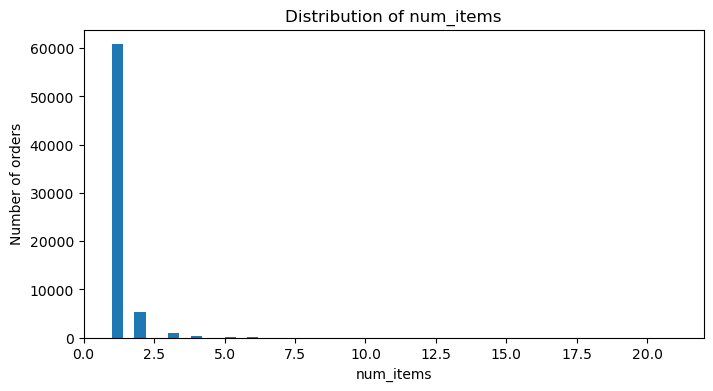

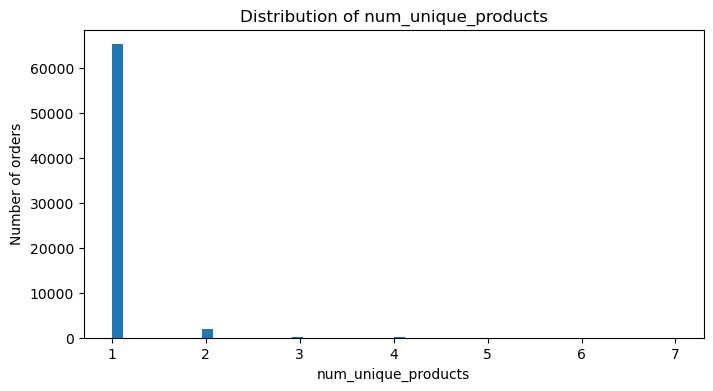

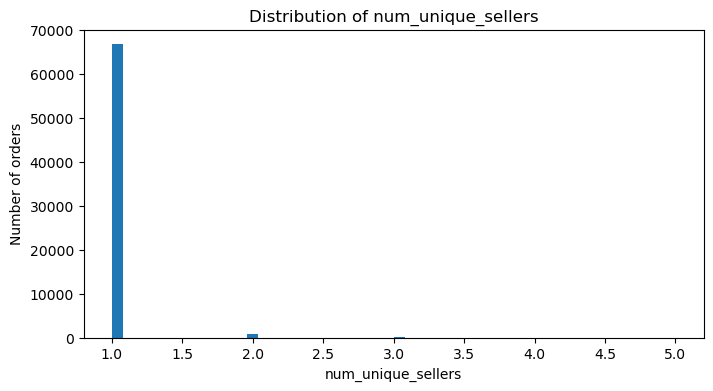

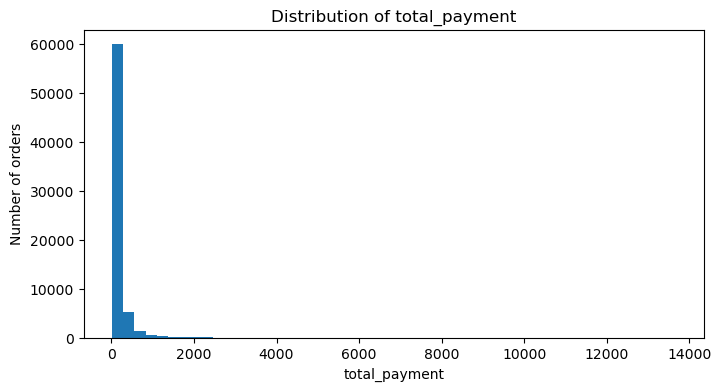

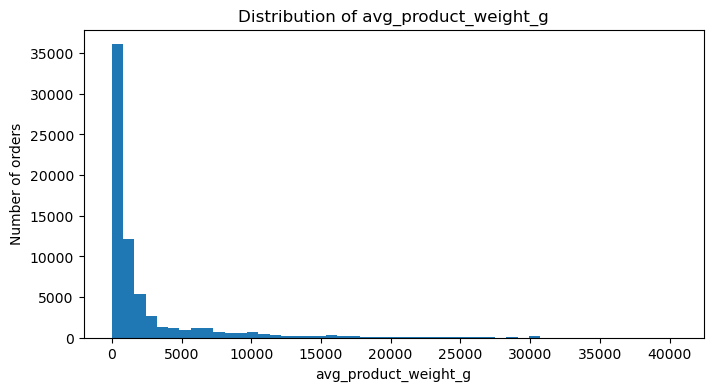

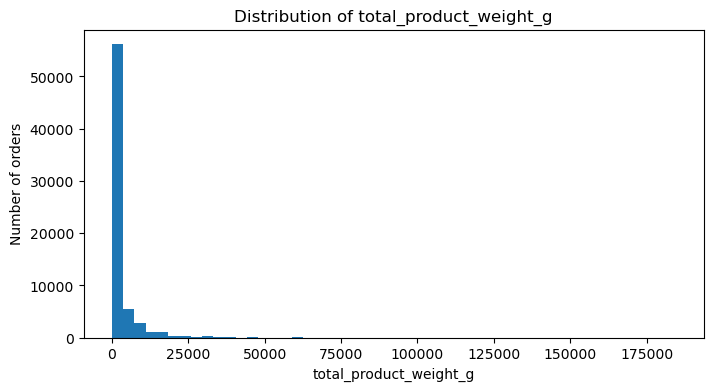

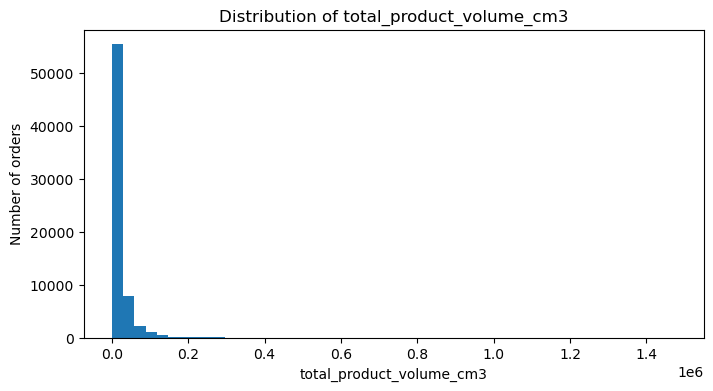

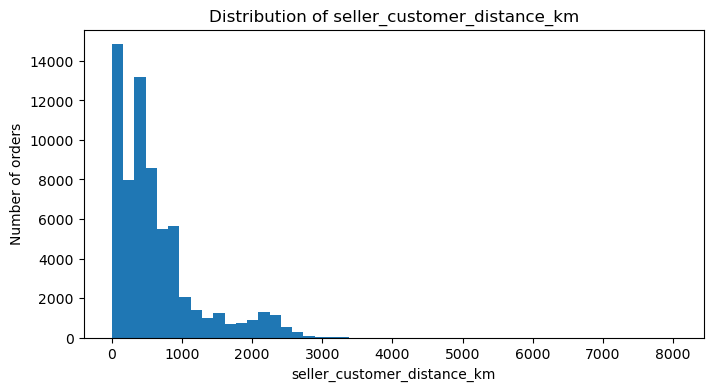

تم ضغط جميع الصور بنجاح في ملف charts_archive.zip!


In [17]:
import shutil
import os

# إنشاء مجلد باسم "my_charts" إذا لم يكن موجوداً
output_dir = "my_charts"
os.makedirs(output_dir, exist_ok=True)

numeric_features = [
    "total_price",
    "total_freight",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "total_payment",
    "avg_product_weight_g",
    "total_product_weight_g",
    "total_product_volume_cm3",
    "seller_customer_distance_km"
]

for col in numeric_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        train[col].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of orders")
    
    # سطر الحفظ الذكي: يحفظ كل صورة باسم العمود الخاص بها
    plt.savefig(f"{output_dir}/{col}_chart.png", dpi=300, bbox_inches="tight")
    plt.show()

shutil.make_archive("charts_archive", 'zip', output_dir)
print("تم ضغط جميع الصور بنجاح في ملف charts_archive.zip!")